In [14]:
import sys
import importlib
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, precision_recall_curve, auc, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Asegurar que la raíz del proyecto esté en PYTHONPATH
root = Path.cwd().resolve()
if (root / 'src').exists():
    pass
elif (root.parent / 'src').exists():
    root = root.parent
if str(root) not in sys.path:
    sys.path.append(str(root))

torch.manual_seed(42)
np.random.seed(42)

import src.gnn_model as gnn_model
importlib.reload(gnn_model)
from src.graph_dataset import load_elliptic_graph
from src.gnn_model import GCNClassifier, GATClassifier

# 1. Cargar Datos y Grafo
data, _ = load_elliptic_graph(
    features_path=str(root / 'data' / 'raw' / 'elliptic_txs_features.csv'),
    classes_path=str(root / 'data' / 'raw' / 'elliptic_txs_classes.csv'),
    edgelist_path=str(root / 'data' / 'raw' / 'elliptic_txs_edgelist.csv')
)


Cargando archivos de datos...
Grafo construido con éxito:
   - Nodos (N): 203769
   - Aristas (E): 234355
   - Dimensión de características: 165
   - Etiquetados (Lícitos/Ilícitos): 46564


In [25]:
# 2. Creación de Máscaras Temporales
# Entrenamos solo sobre nodos etiquetados (y != -1)
train_mask = (data.time_step <= 34) & (data.y != -1)
val_mask = (data.time_step >= 35) & (data.time_step <= 41) & (data.y != -1)
test_mask = (data.time_step >= 42) & (data.y != -1)

# Ajuste defensivo por si el split temporal produce muy pocos nodos en validación/test
if val_mask.sum().item() == 0:
    val_mask = (data.time_step >= 35) & (data.time_step <= 45) & (data.y != -1)
if test_mask.sum().item() == 0:
    test_mask = (data.time_step >= 42) & (data.y != -1)

print(f"Nodos Train: {train_mask.sum().item()}")
print(f"Nodos Val:   {val_mask.sum().item()}")
print(f"Nodos Test:  {test_mask.sum().item()}")


Nodos Train: 29894
Nodos Val:   7829
Nodos Test:  8841


In [16]:
# 3. Manejo de Desbalance de Clases (Peso para la clase 1 - Ilícita)
y_train = data.y[train_mask]
num_licit = (y_train == 0).sum().item()
num_illicit = (y_train == 1).sum().item()

if num_illicit == 0:
    raise ValueError('No hay ejemplos ilícitos en el split de entrenamiento; ajusta las máscaras temporales.')

# Peso inversamente proporcional a la frecuencia
pos_weight = torch.tensor([1.0, num_licit / num_illicit], dtype=torch.float32)
print(f"Pesos de Clase (Lícita: {pos_weight[0]:.2f}, Ilícita: {pos_weight[1]:.2f})")


Pesos de Clase (Lícita: 1.00, Ilícita: 7.63)


In [17]:
# 4. Configurar Modelo, Optimizador y Criterio
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)
pos_weight = pos_weight.to(device)

model = GCNClassifier(in_channels=data.num_node_features, hidden_channels=64, out_channels=2, dropout=0.2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss(weight=pos_weight)

model_dir = root / 'models'
model_dir.mkdir(exist_ok=True)

best_state = None
best_val_prauc = 0.0
best_epoch = 0
patience = 15
epochs = 150
wait = 0


In [18]:
# 5. Bucle de Entrenamiento
epochs = 150
patience = 15

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        out_val = model(data.x, data.edge_index)
        probs_val = torch.softmax(out_val[val_mask], dim=1)[:, 1].cpu().numpy()
        y_val_true = data.y[val_mask].cpu().numpy()
        precision, recall, _ = precision_recall_curve(y_val_true, probs_val)
        val_prauc = auc(recall, precision)

    if val_prauc > best_val_prauc + 1e-6:
        best_val_prauc = val_prauc
        best_epoch = epoch
        wait = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        torch.save(model.state_dict(), model_dir / 'best_gcn_model.pth')
    else:
        wait += 1

    if epoch % 10 == 0 or epoch == epochs:
        print(f"Epoch {epoch:03d} | Loss Train: {loss.item():.4f} | Val PR-AUC: {val_prauc:.4f}")

    if wait >= patience:
        print(f"Early stopping en la época {epoch} por falta de mejora en Val PR-AUC.")
        break


Epoch 010 | Loss Train: 0.5176 | Val PR-AUC: 0.4486
Epoch 020 | Loss Train: 0.4232 | Val PR-AUC: 0.4422
Epoch 030 | Loss Train: 0.3603 | Val PR-AUC: 0.5103
Epoch 040 | Loss Train: 0.3127 | Val PR-AUC: 0.5586
Epoch 050 | Loss Train: 0.2827 | Val PR-AUC: 0.5808
Epoch 060 | Loss Train: 0.2572 | Val PR-AUC: 0.6039
Epoch 070 | Loss Train: 0.2429 | Val PR-AUC: 0.6226
Epoch 080 | Loss Train: 0.2258 | Val PR-AUC: 0.6254
Epoch 090 | Loss Train: 0.2172 | Val PR-AUC: 0.6210
Early stopping en la época 90 por falta de mejora en Val PR-AUC.



--- RESULTADOS GCN (TEST SET) ---
PR-AUC Test: 0.4029

[Umbral por defecto = 0.5]
              precision    recall  f1-score   support

  Lícita (0)       0.98      0.58      0.73      8433
 Ilícita (1)       0.08      0.77      0.15       408

    accuracy                           0.59      8841
   macro avg       0.53      0.67      0.44      8841
weighted avg       0.94      0.59      0.70      8841

Umbral óptimo encontrado en validación: 0.80 con F1 = 0.5727

[Umbral optimizado en validación]
              precision    recall  f1-score   support

  Lícita (0)       0.97      0.95      0.96      8433
 Ilícita (1)       0.30      0.46      0.36       408

    accuracy                           0.93      8841
   macro avg       0.64      0.70      0.66      8841
weighted avg       0.94      0.93      0.93      8841



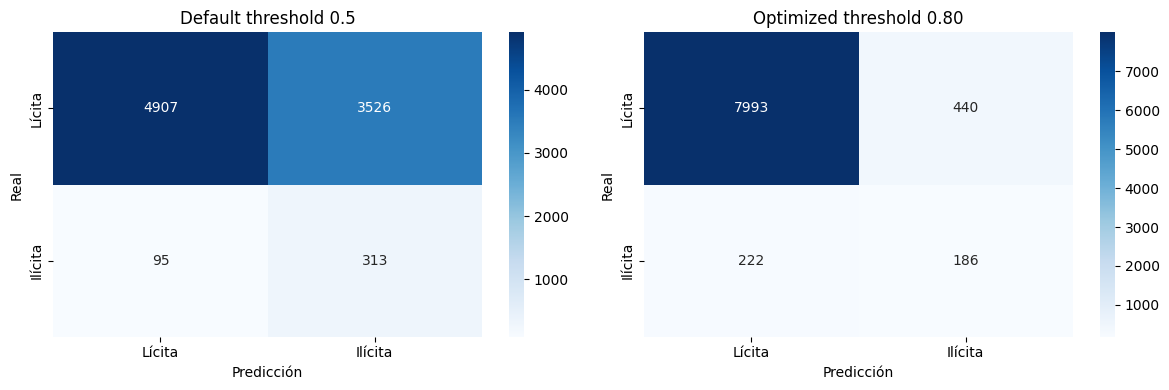

In [20]:
# 6. Evaluación Final en el Test Set (Pasos Temporales 42-49)
model.load_state_dict(torch.load(model_dir / 'best_gcn_model.pth', map_location=device))
model.eval()

with torch.no_grad():
    logits_test = model(data.x, data.edge_index)[test_mask]
    probs_test = torch.softmax(logits_test, dim=1)[:, 1].cpu().numpy()
    y_test_true = data.y[test_mask].cpu().numpy()

# Métricas con umbral por defecto (0.5)
default_preds = (probs_test >= 0.5).astype(int)
precision_default, recall_default, _ = precision_recall_curve(y_test_true, probs_test)
test_prauc = auc(recall_default, precision_default)
print("\n--- RESULTADOS GCN (TEST SET) ---")
print(f"PR-AUC Test: {test_prauc:.4f}")
print("\n[Umbral por defecto = 0.5]")
print(classification_report(y_test_true, default_preds, target_names=['Lícita (0)', 'Ilícita (1)']))

# Búsqueda del umbral óptimo en validación
with torch.no_grad():
    val_logits = model(data.x, data.edge_index)[val_mask]
    val_probs = torch.softmax(val_logits, dim=1)[:, 1].cpu().numpy()
    y_val_true = data.y[val_mask].cpu().numpy()

best_threshold = 0.5
best_f1 = 0.0
for threshold in [t / 10 for t in range(1, 10)]:
    preds_val = (val_probs >= threshold).astype(int)
    report = classification_report(y_val_true, preds_val, output_dict=True, zero_division=0)
    f1 = report['1']['f1-score']
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"Umbral óptimo encontrado en validación: {best_threshold:.2f} con F1 = {best_f1:.4f}")

# Evaluación con umbral óptimo en test
optimized_preds = (probs_test >= best_threshold).astype(int)
print("\n[Umbral optimizado en validación]")
print(classification_report(y_test_true, optimized_preds, target_names=['Lícita (0)', 'Ilícita (1)']))

# Matrices de Confusión
cm_default = confusion_matrix(y_test_true, default_preds)
cm_opt = confusion_matrix(y_test_true, optimized_preds)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues', xticklabels=['Lícita', 'Ilícita'], yticklabels=['Lícita', 'Ilícita'], ax=axes[0])
axes[0].set_title('Default threshold 0.5')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues', xticklabels=['Lícita', 'Ilícita'], yticklabels=['Lícita', 'Ilícita'], ax=axes[1])
axes[1].set_title(f'Optimized threshold {best_threshold:.2f}')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
plt.tight_layout()
plt.show()


In [21]:
import numpy as np
import torch
from sklearn.metrics import average_precision_score, f1_score, precision_recall_curve

# Búsqueda rápida de hiperparámetros para el GCN usando 3 configuraciones

def train_gcn(config, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = GCNClassifier(
        in_channels=data.num_node_features,
        hidden_channels=config['hidden_channels'],
        out_channels=2,
        dropout=config['dropout'],
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    criterion = nn.CrossEntropyLoss(weight=pos_weight.to(device))

    best_val = -1.0
    best_state = None
    patience = 8
    wait = 0

    for epoch in range(config['epochs']):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = criterion(out[train_mask], data.y[train_mask])
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            out_val = model(data.x, data.edge_index)
            probs_val = torch.softmax(out_val[val_mask], dim=1)[:, 1].cpu().numpy()
            y_val_true = data.y[val_mask].cpu().numpy()
            precision, recall, _ = precision_recall_curve(y_val_true, probs_val)
            val_prauc = average_precision_score(y_val_true, probs_val)

        if val_prauc > best_val + 1e-4:
            best_val = val_prauc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        out_test = model(data.x, data.edge_index)
        probs_test = torch.softmax(out_test[test_mask], dim=1)[:, 1].cpu().numpy()
        y_test_true = data.y[test_mask].cpu().numpy()

    thresholds = np.linspace(0.1, 0.9, 17)
    best_f1 = -1.0
    best_thr = 0.5
    for thr in thresholds:
        preds = (probs_test >= thr).astype(int)
        score = f1_score(y_test_true, preds, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_thr = thr

    return {
        'config': config,
        'val_prauc': best_val,
        'test_prauc': average_precision_score(y_test_true, probs_test),
        'best_threshold': best_thr,
        'best_f1': best_f1,
    }

configs = [
    {'hidden_channels': 64, 'dropout': 0.2, 'lr': 1e-3, 'weight_decay': 1e-4, 'epochs': 60},
    {'hidden_channels': 128, 'dropout': 0.3, 'lr': 5e-4, 'weight_decay': 1e-4, 'epochs': 60},
    {'hidden_channels': 96, 'dropout': 0.25, 'lr': 7e-4, 'weight_decay': 5e-5, 'epochs': 70},
]

results = [train_gcn(cfg) for cfg in configs]
for res in results:
    print(res)

best_result = max(results, key=lambda x: x['test_prauc'])
print('MEJOR CONFIGURACIÓN:', best_result)


{'config': {'hidden_channels': 64, 'dropout': 0.2, 'lr': 0.001, 'weight_decay': 0.0001, 'epochs': 60}, 'val_prauc': 0.4973265102806267, 'test_prauc': 0.2798460528895872, 'best_threshold': np.float64(0.55), 'best_f1': 0.30874785591766724}
{'config': {'hidden_channels': 128, 'dropout': 0.3, 'lr': 0.0005, 'weight_decay': 0.0001, 'epochs': 60}, 'val_prauc': 0.4841498861458028, 'test_prauc': 0.29796141969266177, 'best_threshold': np.float64(0.8), 'best_f1': 0.3401360544217687}
{'config': {'hidden_channels': 96, 'dropout': 0.25, 'lr': 0.0007, 'weight_decay': 5e-05, 'epochs': 70}, 'val_prauc': 0.6148636192527329, 'test_prauc': 0.39152576413861095, 'best_threshold': np.float64(0.85), 'best_f1': 0.415973377703827}
MEJOR CONFIGURACIÓN: {'config': {'hidden_channels': 96, 'dropout': 0.25, 'lr': 0.0007, 'weight_decay': 5e-05, 'epochs': 70}, 'val_prauc': 0.6148636192527329, 'test_prauc': 0.39152576413861095, 'best_threshold': np.float64(0.85), 'best_f1': 0.415973377703827}
